In [ ]:
!unzip -q auta.zip -d dataset/

In [ ]:
import torch
import torchvision.datasets as datasets
from torchvision import transforms as T
from torch.utils.data import random_split, DataLoader

size = 224
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
tfs = T.Compose([
    T.Resize(size=(size, size)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

root = "dataset"
dataset = datasets.ImageFolder(root=root, transform=tfs)

classes = dataset.class_to_idx

generator = torch.Generator().manual_seed(2025)
tr_len = int(0.8 * len(dataset))
vl_len = len(dataset) - tr_len

tr_ds, vl_ds = random_split(dataset, [tr_len, vl_len], generator=generator)

bs = 16
tr_dl_fast = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=2, pin_memory=True)
val_dl_fast = DataLoader(vl_ds, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)

print(f"Baza załadowana w trybie FAST: {len(dataset)} zdjęć łącznie.")
print(f"Klasy: {classes}")

Baza załadowana w trybie FAST: 4597 zdjęć łącznie.
Klasy: {'Acura': 0, 'Alfa Romeo': 1, 'Aston Martin': 2, 'Audi': 3, 'BMW': 4, 'Bentley': 5, 'Bugatti': 6, 'Buick': 7, 'Cadillac': 8, 'Chevrolet': 9, 'Chrysler': 10, 'Citroen': 11, 'Daewoo': 12, 'Dodge': 13, 'Ferrari': 14, 'Fiat': 15, 'Ford': 16, 'GMC': 17, 'Genesis': 18, 'Honda': 19, 'Hudson': 20, 'Hyundai': 21, 'Infiniti': 22, 'Jaguar': 23, 'Jeep': 24, 'Kia': 25, 'Land Rover': 26, 'Lexus': 27, 'Lincoln': 28, 'MG': 29, 'Maserati': 30, 'Mazda': 31, 'Mercedes-Benz': 32, 'Mini': 33, 'Mitsubishi': 34, 'Nissan': 35, 'Oldsmobile': 36, 'Peugeot': 37, 'Pontiac': 38, 'Porsche': 39, 'Ram Trucks': 40, 'Renault': 41, 'Saab': 42, 'Studebaker': 43, 'Subaru': 44, 'Suzuki': 45, 'Tesla': 46, 'Toyota': 47, 'Volkswagen': 48, 'Volvo': 49}


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

torch.backends.cudnn.benchmark = True

class ProstaSiećCNN(nn.Module):
    def __init__(self, num_classes):
        super(ProstaSiećCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Trening SZYBKI Baseline na: {device}")

model = ProstaSiećCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

scaler = torch.amp.GradScaler('cuda')

epochs = 6
print(f"\n ROZPOCZĘCIE TRENINGU ({epochs} epok) ")

for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0

    for images, labels in tqdm(tr_dl_fast, desc=f"Epoka {epoch+1}/{epochs}", colour="green"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_acc += (torch.argmax(outputs, dim=1) == labels).sum().item()

    model.eval()
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_dl_fast:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_acc += (torch.argmax(outputs, dim=1) == labels).sum().item()

    t_acc = train_acc / len(tr_dl_fast.dataset)
    v_acc = val_acc / len(val_dl_fast.dataset)

    print(f" Wynik uczenia: {t_acc*100:.1f}% | Wynik na nowych zdjęciach: {v_acc*100:.1f}%")

🚀 Trening SZYBKI Baseline na: cuda

 ROZPOCZĘCIE TRENINGU (6 epok) 


Epoka 1/6: 100%|██████████| 230/230 [00:10<00:00, 22.93it/s]


 Wynik uczenia: 3.0% | Wynik na nowych zdjęciach: 3.6%


Epoka 2/6: 100%|██████████| 230/230 [00:10<00:00, 22.79it/s]


 Wynik uczenia: 4.8% | Wynik na nowych zdjęciach: 3.2%


...

 Wynik uczenia: 37.6% | Wynik na nowych zdjęciach: 8.2%


Epoka 5/6: 100%|██████████| 230/230 [00:09<00:00, 23.53it/s]


 Wynik uczenia: 89.9% | Wynik na nowych zdjęciach: 9.0%


Epoka 6/6: 100%|██████████| 230/230 [00:09<00:00, 24.53it/s]


 Wynik uczenia: 98.0% | Wynik na nowych zdjęciach: 9.8%



🔍 Generowanie Macierzy Pomyłek dla modelu Baseline (Etap 1)...
 Rysowanie wykresu...


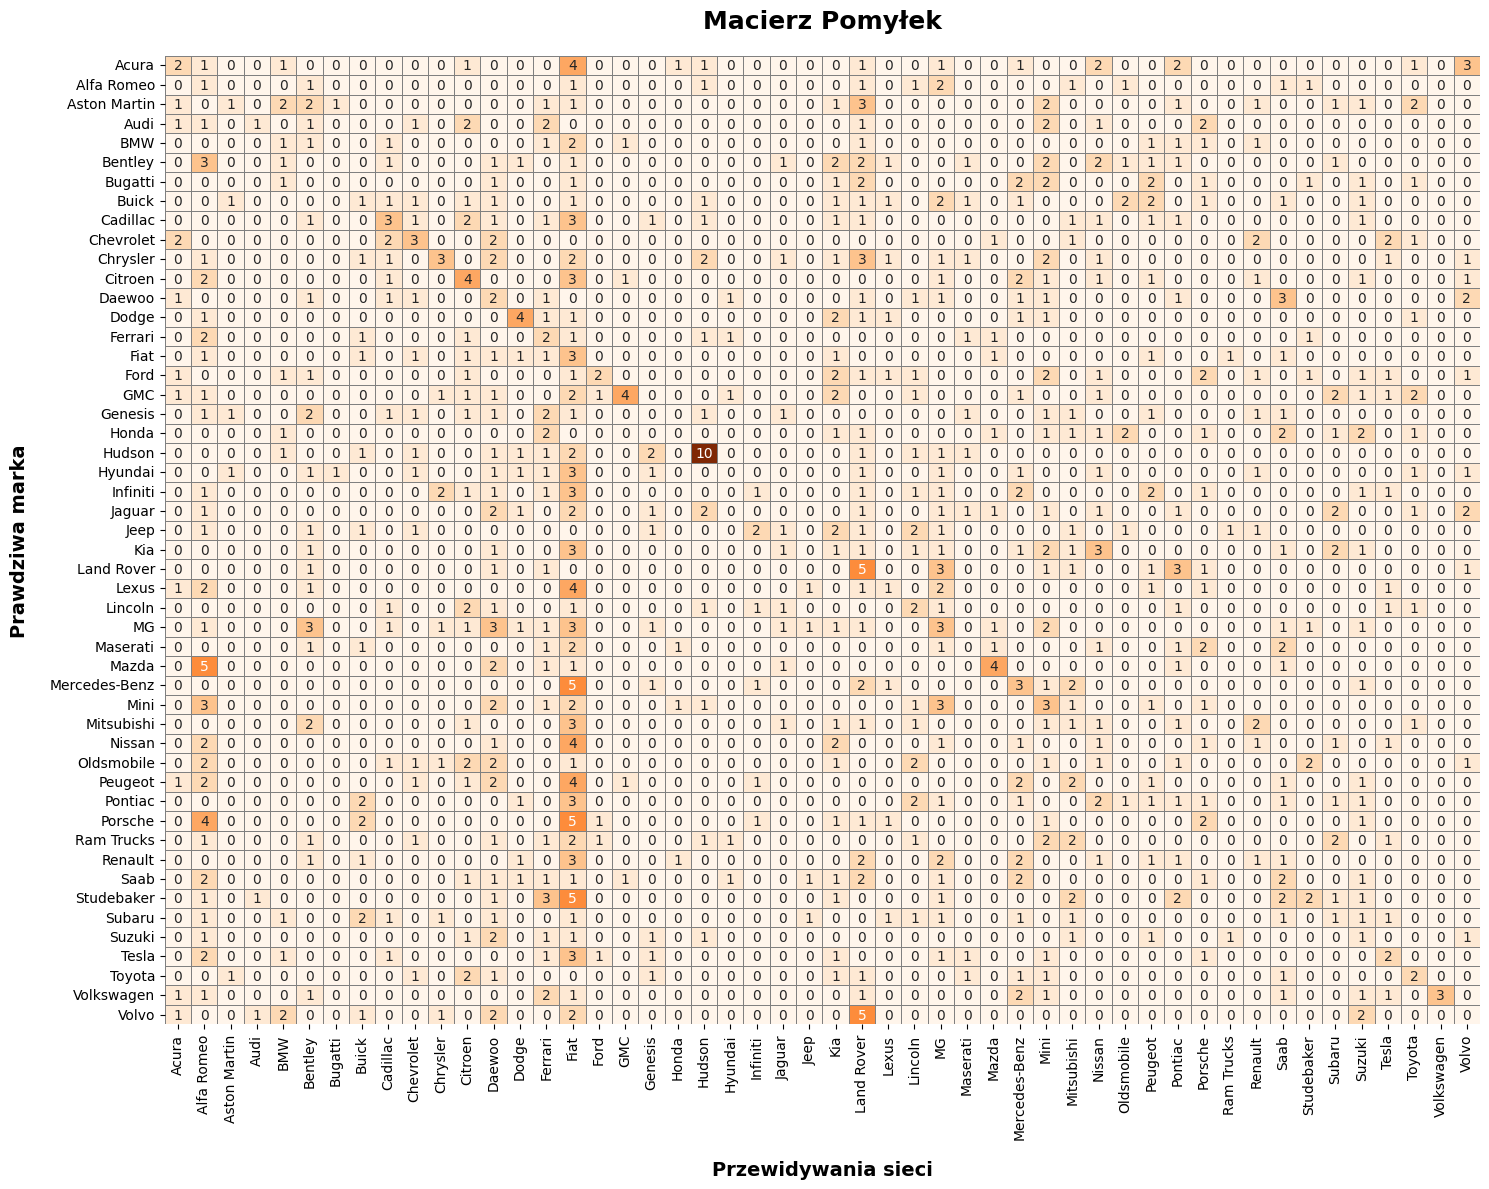

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

print("\n Generowanie Macierzy Pomyłek dla modelu Baseline (Etap 1)...")

model.eval()

y_prawdziwe = []
y_przewidziane = []

nazwy_klas = list(classes.keys())

with torch.no_grad():
    for images, labels in val_dl_fast:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        y_prawdziwe.extend(labels.cpu().numpy())
        y_przewidziane.extend(preds.cpu().numpy())

print(" Rysowanie wykresu...")

cm = confusion_matrix(y_prawdziwe, y_przewidziane)

plt.figure(figsize=(15, 12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=nazwy_klas, yticklabels=nazwy_klas,
            cbar=False, linewidths=0.5, linecolor='gray')

plt.xlabel('Przewidywania sieci', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Prawdziwa marka', fontsize=14, fontweight='bold', labelpad=15)
plt.title('Macierz Pomyłek', fontsize=18, fontweight='bold', pad=20)

plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.show()